# Class 7 - Exercise notebook

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

import numpy as np
import pandas as pd
from sklearn.linear_model import  LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Hospital-Da-Luz-Learning-Health/MLCatolica24/main/Aula%206%20-%20Supervised%20Learning%20II/data/diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Choose your target column
target_col = "Outcome"

## Prepare the data for training

In [5]:
# Split df into X and y
X = df.drop(target_col, axis=1)
y = df[target_col]

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# dataset standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the model

In [8]:
# Choose a model and fit it with your training data
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

# Model Evaluation

In [9]:
# Make the predictions
y_pred = model.predict(X_test)

In [10]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [12]:
y_test.to_numpy()

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0])

## Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

In [14]:
# Compute the accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7532467532467533

## Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

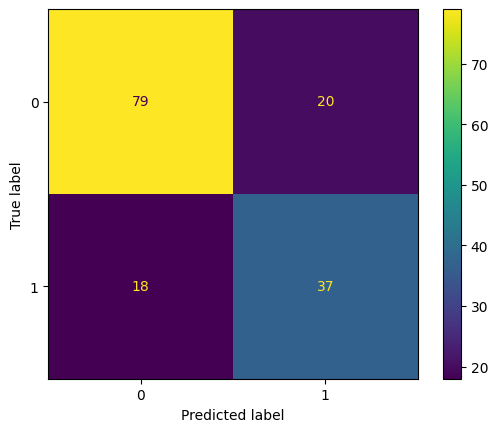

In [15]:
# Compute and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()

## Precision, Recall and F1-score

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [17]:
## Compute the precision
precision = precision_score(y_test, y_pred)

## Compute the Recall
recall = recall_score(y_test, y_pred)

## Compute the F1-score
f1 = f1_score(y_test, y_pred)

In [18]:
precision

0.6491228070175439

In [21]:
recall

0.6727272727272727

In [22]:
f1

0.6607142857142857

## Threshold Analysis

In [20]:
y_predict_probs = model.predict_proba(X_test)[:, 1]
y_predict_probs

array([0.27736383, 0.18595977, 0.11465752, 0.17139617, 0.46843793,
       0.43994646, 0.01619214, 0.65955117, 0.5361637 , 0.77058281,
       0.25393899, 0.89141279, 0.3328725 , 0.31288864, 0.08534894,
       0.38631714, 0.13940673, 0.07654033, 0.85780987, 0.55521674,
       0.20841823, 0.07908615, 0.53120788, 0.09543917, 0.53497997,
       0.87988189, 0.12445729, 0.03105382, 0.24801687, 0.1194984 ,
       0.90715973, 0.86727835, 0.75769995, 0.83300134, 0.62049806,
       0.6859238 , 0.96539288, 0.24975122, 0.5087476 , 0.72360145,
       0.07120025, 0.59431639, 0.58176342, 0.33064973, 0.02881938,
       0.50697619, 0.65016588, 0.22505347, 0.36974282, 0.95579301,
       0.04959779, 0.66377551, 0.8097042 , 0.24806187, 0.09427575,
       0.04265584, 0.77095657, 0.00599514, 0.41303377, 0.74746918,
       0.73572228, 0.34807356, 0.20057534, 0.21605177, 0.07785928,
       0.61718538, 0.05196959, 0.7259848 , 0.03900445, 0.71522747,
       0.67587109, 0.07200265, 0.18294234, 0.11486192, 0.09280

In [24]:
## Now, compute the precision, recall and f1 across the probability thresholds and plot the results in a dataframe
ths = np.arange(0.1,1,step=0.1)

results = []
for decision_threshold in ths:
    th_preds = (y_predict_probs > decision_threshold).astype(int)

    recall = recall_score(th_preds, y_test)
    precision = precision_score(th_preds, y_test)

    results.append({"decision_threshold":decision_threshold,"recall":recall,"precision":precision})

results = pd.DataFrame(results).set_index('decision_threshold')
results

,recall,precision
decision_threshold,,
0.1,0.446281,0.981818
0.2,0.494949,0.890909
0.3,0.545455,0.763636
0.4,0.584615,0.690909
0.5,0.649123,0.672727
0.6,0.750000,0.600000
0.7,0.818182,0.490909
0.8,0.875000,0.254545
0.9,0.750000,0.054545


## ROC (Receiver Operating Characteristic)

In [25]:
from sklearn.metrics import roc_auc_score, roc_curve

In [26]:
### Use roc_curve function to compute the ROC curve, namely the fpr, tpr and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_predict_probs)

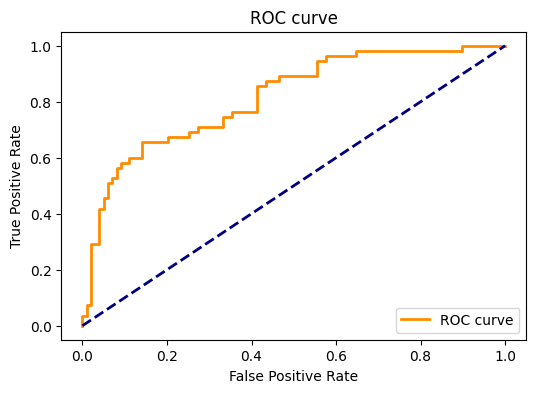

In [29]:
# plot the curve
plt.figure(figsize=(6,4));
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve');
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--'); # random model
plt.xlabel('False Positive Rate');
plt.ylabel('True Positive Rate');
plt.title('ROC curve');
plt.legend(loc="lower right");
plt.show();

In [37]:
roc_auc_score(y_test, y_predict_probs)

np.float64(0.8146923783287419)

## Precision-recall Curve and Average Precision

In [34]:
from sklearn.metrics import average_precision_score, precision_recall_curve

In [35]:
## Use precision_recall_curve function to compute the precision, recall and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_predict_probs)

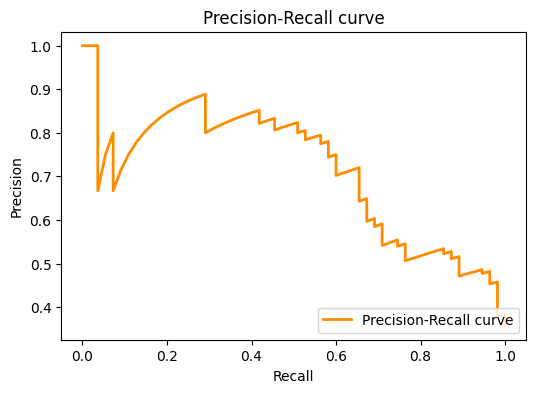

In [36]:
# Plot the precision-recall curve
# plot the curve
plt.figure(figsize=(6,4));
plt.plot(recall, precision, color='darkorange', lw=2, label='Precision-Recall curve');
plt.xlabel('Recall');
plt.ylabel('Precision');
plt.title('Precision-Recall curve');
plt.legend(loc="lower right");
plt.show();

In [38]:
average_precision_score(y_test, y_predict_probs)

np.float64(0.7159509855394156)